# Data Pre-processing

In [150]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 

#necessary libraries

### Handling Null Values

In [151]:
#Reading the csv file to fetch the data

volunteer = pd.read_csv('https://raw.githubusercontent.com/labib15/Machine-Learning-Datasets/main/volunteer_opportunities.csv')
volunteer.head(3) #3-> shows the first 3 rows 

,opportunity_id,content_id,vol_requests,event_time,title,hits,summary,is_priority,category_id,category_desc,...,end_date_date,status,Latitude,Longitude,Community Board,Community Council,Census Tract,BIN,BBL,NTA
0,4996,37004,50,0,Volunteers Needed For Rise Up & Stay Put! Home...,737,Building on successful events last summer and ...,NaN,NaN,NaN,...,July 30 2011,approved,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,5008,37036,2,0,Web designer,22,Build a website for an Afghan business,NaN,1.0,Strengthening Communities,...,February 01 2011,approved,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,5016,37143,20,0,Urban Adventures - Ice Skating at Lasker Rink,62,Please join us and the students from Mott Hall...,NaN,1.0,Strengthening Communities,...,January 29 2011,approved,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [152]:
#returning (rows,columns) available in the data
volunteer.shape

(665, 35)

In [153]:
#counting the number of null values in each column
volunteer.isnull().sum()

opportunity_id          0
content_id              0
vol_requests            0
event_time              0
title                   0
hits                    0
summary                 0
is_priority           603
category_id            48
category_desc          48
amsl                  665
amsl_unit             665
org_title               0
org_content_id          0
addresses_count         0
locality               70
region                  0
postalcode              6
primary_loc           665
display_url             0
recurrence_type         0
hours                   0
created_date            0
last_modified_date      0
start_date_date         0
end_date_date           0
status                  0
Latitude              665
Longitude             665
Community Board       665
Community Council     665
Census Tract          665
BIN                   665
BBL                   665
NTA                   665
dtype: int64

### Removing a Column

In [154]:
#Removing a column
volunteer = volunteer.drop(['BIN','BBL','NTA'], axis = 1) #dropping 3 columns
#axis = 1 means column , axis = 0 means row 
volunteer.shape

(665, 32)

### Removing a Row

In [155]:

#number of null rows
null_vals=volunteer[volunteer['category_desc'].isnull()]
print("Number of null values" , null_vals.shape)
#number of nonNull rows
nonNull_vals=volunteer[volunteer['category_desc'].notnull()]
print("Number of non-null values",nonNull_vals.shape
)



Number of null values (48, 32)
Number of non-null values (617, 32)


In [156]:
#Old shape 
print("Old shape before removing the rows",volunteer.shape)

volunteer = volunteer.dropna(axis=0 , subset= ['category_desc'])

print("New shape after removing the rows",volunteer.shape)

Old shape before removing the rows (665, 32)
New shape after removing the rows (617, 32)


### Imputing values 

In [157]:
sales=pd.read_csv('https://raw.githubusercontent.com/labib15/Machine-Learning-Datasets/refs/heads/main/sales.csv', index_col = ['month'])
sales

,eggs,salt,spam
month,,,
Jan,47,12.0,17
Feb,110,50.0,31
Mar,221,NaN,72
Apr,77,87.0,20
May,132,NaN,52
Jun,205,60.0,55


In [158]:
#Putting a fixed value in NaN
imputed_sales = sales.fillna(50)
imputed_sales



,eggs,salt,spam
month,,,
Jan,47,12.0,17
Feb,110,50.0,31
Mar,221,50.0,72
Apr,77,87.0,20
May,132,50.0,52
Jun,205,60.0,55


In [159]:
sales = pd.read_csv('https://raw.githubusercontent.com/labib15/Machine-Learning-Datasets/refs/heads/main/sales.csv', index_col = ['month'])
sales.head(10)

,eggs,salt,spam
month,,,
Jan,47,12.0,17
Feb,110,50.0,31
Mar,221,NaN,72
Apr,77,87.0,20
May,132,NaN,52
Jun,205,60.0,55


In [160]:
sales[['salt']]


,salt
month,
Jan,12.0
Feb,50.0
Mar,NaN
Apr,87.0
May,NaN
Jun,60.0


In [161]:
#Using Simple Imputer

from sklearn.impute import SimpleImputer

#Finding the average values and placing it in the NaN
#making the engine for imputation
impute = SimpleImputer(missing_values= np.nan , strategy= 'mean')

# .fit() makes the imputer scan the data and figure out the mean
impute.fit(sales[['salt']])

#transform uses the value from .fit() and stores it in the sales['salt'] 
sales['salt'] = impute.transform(sales[['salt']])

#after transformation
sales[['salt']]



,salt
month,
Jan,12.00
Feb,50.00
Mar,52.25
Apr,87.00
May,52.25
Jun,60.00


# Feature Engineering

In [162]:
hiking = pd.read_json('https://raw.githubusercontent.com/labib15/Machine-Learning-Datasets/refs/heads/main/hiking.json')
hiking.head()


,Prop_ID,Name,Location,Park_Name,Length,Difficulty,Other_Details,Accessible,Limited_Access,lat,lon
0,B057,Salt Marsh Nature Trail,"Enter behind the Salt Marsh Nature Center, loc...",Marine Park,0.8 miles,NaN,<p>The first half of this mile-long trail foll...,Y,N,NaN,NaN
1,B073,Lullwater,Enter Park at Lincoln Road and Ocean Avenue en...,Prospect Park,1.0 mile,Easy,Explore the Lullwater to see how nature thrive...,N,N,NaN,NaN
2,B073,Midwood,Enter Park at Lincoln Road and Ocean Avenue en...,Prospect Park,0.75 miles,Easy,Step back in time with a walk through Brooklyn...,N,N,NaN,NaN
3,B073,Peninsula,Enter Park at Lincoln Road and Ocean Avenue en...,Prospect Park,0.5 miles,Easy,Discover how the Peninsula has changed over th...,N,N,NaN,NaN
4,B073,Waterfall,Enter Park at Lincoln Road and Ocean Avenue en...,Prospect Park,0.5 miles,Easy,Trace the source of the Lake on the Waterfall ...,N,N,NaN,NaN


In [163]:
#displays column informations
hiking.info()

<class 'pandas.DataFrame'>
RangeIndex: 33 entries, 0 to 32
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Prop_ID         33 non-null     str    
 1   Name            33 non-null     str    
 2   Location        33 non-null     str    
 3   Park_Name       33 non-null     str    
 4   Length          29 non-null     str    
 5   Difficulty      27 non-null     str    
 6   Other_Details   31 non-null     str    
 7   Accessible      33 non-null     str    
 8   Limited_Access  33 non-null     str    
 9   lat             0 non-null      float64
 10  lon             0 non-null      float64
dtypes: float64(2), str(9)
memory usage: 3.0 KB


In [164]:
#Prints out the unique/non-duplicate elements present under the column
hiking['Accessible'].unique()

<StringArray>
['Y', 'N']
Length: 2, dtype: str

## Feature Selection

1. Dropping columns based on correlation

In [165]:
from sklearn.datasets import load_wine

#load_wine is a pre packaged dataset provided for us to experiment

wine = load_wine()
#converting the built in dataset into a dataframe so that we can treat it like a spreadsheet
wine_df = pd.DataFrame(wine['data']  , columns= wine['feature_names'])

wine_df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [166]:
wine_corr = wine_df.corr()
wine_corr

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
alcohol,1.000000,0.094397,0.211545,-0.310235,0.270798,0.289101,0.236815,-0.155929,0.136698,0.546364,-0.071747,0.072343,0.643720
malic_acid,0.094397,1.000000,0.164045,0.288500,-0.054575,-0.335167,-0.411007,0.292977,-0.220746,0.248985,-0.561296,-0.368710,-0.192011
ash,0.211545,0.164045,1.000000,0.443367,0.286587,0.128980,0.115077,0.186230,0.009652,0.258887,-0.074667,0.003911,0.223626
alcalinity_of_ash,-0.310235,0.288500,0.443367,1.000000,-0.083333,-0.321113,-0.351370,0.361922,-0.197327,0.018732,-0.273955,-0.276769,-0.440597
magnesium,0.270798,-0.054575,0.286587,-0.083333,1.000000,0.214401,0.195784,-0.256294,0.236441,0.199950,0.055398,0.066004,0.393351
total_phenols,0.289101,-0.335167,0.128980,-0.321113,0.214401,1.000000,0.864564,-0.449935,0.612413,-0.055136,0.433681,0.699949,0.498115
flavanoids,0.236815,-0.411007,0.115077,-0.351370,0.195784,0.864564,1.000000,-0.537900,0.652692,-0.172379,0.543479,0.787194,0.494193
nonflavanoid_phenols,-0.155929,0.292977,0.186230,0.361922,-0.256294,-0.449935,-0.537900,1.000000,-0.365845,0.139057,-0.262640,-0.503270,-0.311385
proanthocyanins,0.136698,-0.220746,0.009652,-0.197327,0.236441,0.612413,0.652692,-0.365845,1.000000,-0.025250,0.295544,0.519067,0.330417
color_intensity,0.546364,0.248985,0.258887,0.018732,0.199950,-0.055136,-0.172379,0.139057,-0.025250,1.000000,-0.521813,-0.428815,0.316100


<Axes: >

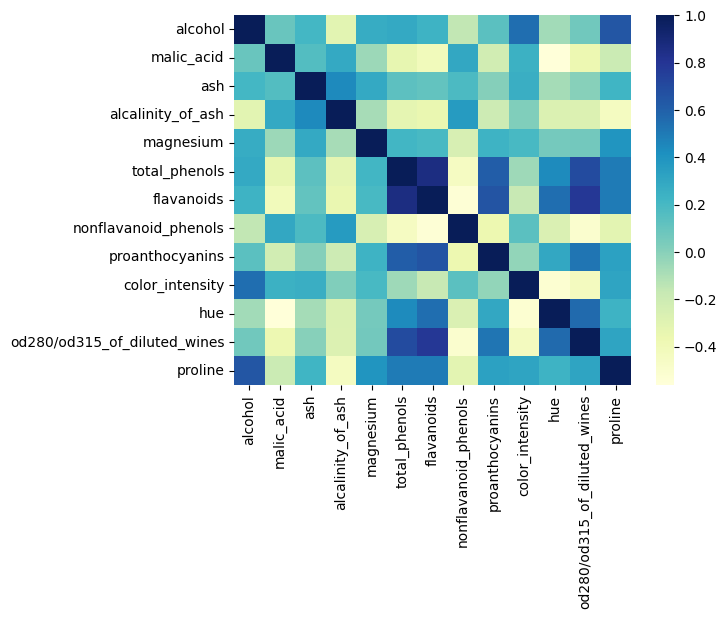

In [167]:
import seaborn as sns

sns.heatmap(wine_corr , cmap = 'YlGnBu')

#clearly flavanoids is very correlated

<Axes: >

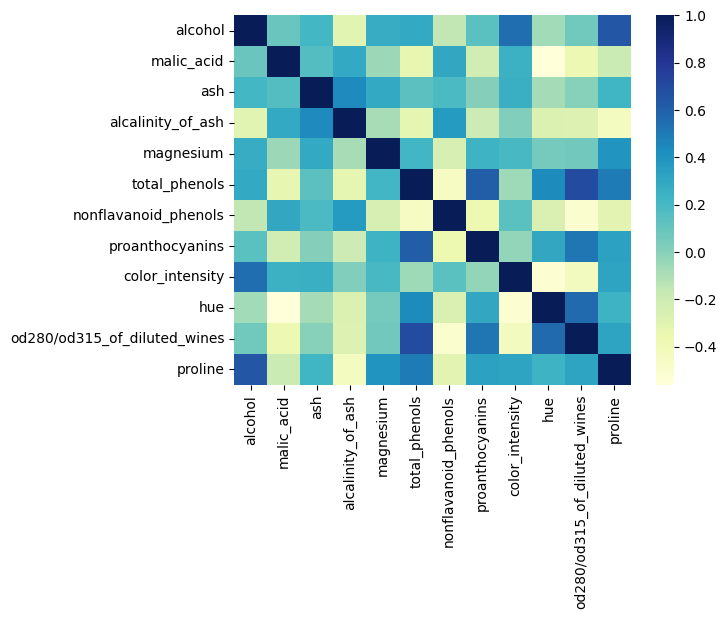

In [168]:
#Dropping flavanoids

wine_df = wine_df.drop('flavanoids' , axis = 1)
wine_corr = wine_df.corr()
sns.heatmap(wine_corr , cmap = 'YlGnBu')


# Standardization/Scaling

In [169]:
from sklearn.datasets import load_breast_cancer

#this chops the dataset into training set and testing set
from sklearn.model_selection import train_test_split

cancer  = load_breast_cancer()
#                                                      the data  , what we really want ,randomizing rows
X_train , X_test , y_train , y_test = train_test_split(cancer.data , cancer.target , random_state=1) 

print(X_train.shape)
print(X_test.shape)

(426, 30)
(143, 30)


## Min Max Scalar

$$\frac{X - X_{min}}{X_{max} - X_{min}}$$

In [170]:
from sklearn.preprocessing import MinMaxScaler

#minMax converts all numbers into 0-1
scaler = MinMaxScaler()
scaler.fit(X_train)

,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False


In [171]:
#Transforming the data
X_train_scaled = scaler.transform(X_train)

#.min or .max returns the min/max value from that row
print("per-feature minimum before scaling:\n {}".format(X_train.min(axis=0)))
print("per-feature maximum before scaling:\n {}".format(X_train.max(axis=0)))

print()


print("per-feature minimum after scaling:\n {}".format(
    X_train_scaled.min(axis=0)))
print("per-feature maximum after scaling:\n {}".format(
    X_train_scaled.max(axis=0)))


per-feature minimum before scaling:
 [6.981e+00 9.710e+00 4.379e+01 1.435e+02 5.263e-02 1.938e-02 0.000e+00
 0.000e+00 1.060e-01 5.024e-02 1.153e-01 3.602e-01 7.570e-01 6.802e+00
 1.713e-03 2.252e-03 0.000e+00 0.000e+00 9.539e-03 8.948e-04 7.930e+00
 1.202e+01 5.041e+01 1.852e+02 7.117e-02 2.729e-02 0.000e+00 0.000e+00
 1.566e-01 5.521e-02]
per-feature maximum before scaling:
 [2.811e+01 3.928e+01 1.885e+02 2.501e+03 1.634e-01 2.867e-01 4.268e-01
 2.012e-01 3.040e-01 9.575e-02 2.873e+00 4.885e+00 2.198e+01 5.422e+02
 3.113e-02 1.354e-01 3.960e-01 5.279e-02 6.146e-02 2.984e-02 3.604e+01
 4.954e+01 2.512e+02 4.254e+03 2.226e-01 9.379e-01 1.170e+00 2.910e-01
 5.774e-01 1.486e-01]

per-feature minimum after scaling:
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0.]
per-feature maximum after scaling:
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1.]


In [172]:
#transforming the test data

X_test_scaled = scaler.transform(X_test)

## Training the Model

In [173]:
from sklearn.neighbors import KNeighborsClassifier
#Used to predict categories 
X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target,random_state=0)

knn=KNeighborsClassifier()

#feeding it the training data
knn.fit(X_train , y_train)

#Accuracy without Scaling:

#comparing it with the testing data
knn.score(X_test , y_test)



0.9370629370629371

In [174]:
scaler = MinMaxScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)

X_test_scaled = scaler.transform(X_test)

#train

knn.fit(X_train_scaled,y_train)

#Accuracy with Scaling:

knn.score(X_test_scaled , y_test)


0.958041958041958

### All Together

In [175]:
# preprocessing using zero mean and unit variance scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)


#Fitting a KNN model on the data
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

prediction = knn.predict(X_test)
print("Prediction:", prediction)

print("Test set score: {:.2f}".format(knn.score(X_test, y_test)))

# Training KNN on the scaled training data
knn.fit(X_train_scaled, y_train)

# scoring on the scaled test set
print("KNN test accuracy after Standard Scalar: {:.2f}".format(knn.score(X_test_scaled, y_test)))

Prediction: [0 1 1 0 1 1 1 1 1 1 0 1 1 0 0 0 1 0 0 0 0 0 1 1 0 1 1 1 1 0 1 0 1 0 1 0 1
 0 1 0 0 1 0 1 0 0 1 1 1 0 0 1 0 1 1 1 1 1 1 0 0 0 1 1 0 1 0 0 0 1 1 0 1 1
 0 1 1 1 1 1 0 0 0 1 0 1 1 1 0 0 1 0 1 1 1 1 0 1 1 1 1 1 1 1 0 1 0 0 0 0 1
 0 0 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 0 1 1 1 1 1 1 0 0 1 1 1 0]
Test set score: 0.92
KNN test accuracy after Standard Scalar: 0.94
